To follow along the treatment in the book, first run

```bash
uv run old_import_products.py
```

The main() function still performs a drop_all() followed by a create_all() as a quick way to reset the database, but keep in mind that recreating the entire database from scratch to make changes gets less viable the more tables there are in the database. Soon you will learn about how to improve this using database migration scripts.


## Many-to-Many Relationship Queries

As you can surely guess, the products and countries relationship objects added to the Country and Product models respectively also simplify the use of the many-to-many relationship in queries.

To try some queries, begin by starting a Python session and importing the needed components:

In [20]:
from db import Session
from models import Product, Manufacturer, Country

In [21]:
from sqlalchemy import select, func
session = Session()

Here is how to get a product and its countries:

In [22]:
p = session.scalar(
    select(Product)
    .where(Product.name == "Timex Sinclair 1000")
)

p

Product(138, "Timex Sinclair 1000", "Manufacturer(70, "Timex Sinclair")", 1982, [Country(3, "USA")], "Z80")

Here the countries relationship uses the default lazy loader, so it implicitly runs a query to get the list of countries when the attribute is accessed for the first time.

Similarly, a country can report its products:

In [23]:
c = session.scalar(
    select(Country)
    .where(Country.name == 'Portugal')
)

c

In [10]:
c.products

AttributeError: 'NoneType' object has no attribute 'products'

Moving on to something more complex, here is a query that returns all the products that have multiple countries, along with how many countries each has:

In [11]:
country_count = func.count(Country.id).label(None)
q = (select(Product, country_count)
     .join(Product.countries)
     .group_by(Product)
     .having(country_count >= 2)
     .order_by(Product.name)
     )

session.execute(q).all()

[(Product(142, "Timex Computer 2068", "Manufacturer(70, "Timex Sinclair")", 1983, [Country(1, "UK"), Country(3, "USA")], "Z80"), 2),
 (Product(139, "Timex Sinclair 1500", "Manufacturer(70, "Timex Sinclair")", 1982, [Country(1, "UK"), Country(3, "USA")], "Z80"), 2),
 (Product(140, "Timex Sinclair 2048", "Manufacturer(70, "Timex Sinclair")", 1984, [Country(1, "UK"), Country(3, "USA")], "Z80"), 2)]

In [12]:
q = (select(Product, func.count(Country.id))
     .join(Product.countries)
     .group_by(Product)
     .having(func.count(Country.id) >= 2)
     .order_by(Product.name)
     )

session.execute(q).all()

[(Product(142, "Timex Computer 2068", "Manufacturer(70, "Timex Sinclair")", 1983, [Country(1, "UK"), Country(3, "USA")], "Z80"), 2),
 (Product(139, "Timex Sinclair 1500", "Manufacturer(70, "Timex Sinclair")", 1982, [Country(1, "UK"), Country(3, "USA")], "Z80"), 2),
 (Product(140, "Timex Sinclair 2048", "Manufacturer(70, "Timex Sinclair")", 1984, [Country(1, "UK"), Country(3, "USA")], "Z80"), 2)]

The join() method in this query is interesting, because a many-to-many relationship cannot be queried with a single join. In fact, it is not possible in SQL to join the products and countries tables directly, since there are no common attributes in them that can be used. In reality, a many-to-many relationship requires a two-step join. First the products table is joined with the products_countries join table, and then products_countries is joined with countries. SQLAlchemy does some invisible work here to make this join work.

In [13]:
print(q)

SELECT products.id, products.name, products.manufacturer_id, products.year, products.cpu, count(countries.id) AS count_1 
FROM products JOIN products_countries AS products_countries_1 ON products.id = products_countries_1.product_id JOIN countries ON countries.id = products_countries_1.country_id GROUP BY products.id, products.name, products.manufacturer_id, products.year, products.cpu 
HAVING count(countries.id) >= :count_2 ORDER BY products.name


The next query obtains the list of manufacturers that operate in the UK:

In [14]:
q = (select(Manufacturer)
     .join(Manufacturer.products)
     .join(Product.countries)
     .where(Country.name == 'UK')
     .order_by(Manufacturer.name)
     .distinct())

session.scalars(q).all()

[Manufacturer(1, "Acorn Computers Ltd"),
 Manufacturer(2, "Amstrad"),
 Manufacturer(6, "Apricot Computers"),
 Manufacturer(12, "Camputers"),
 Manufacturer(21, "Dragon Data"),
 Manufacturer(31, "Grundy Business Systems"),
 Manufacturer(27, "Intelligent Software"),
 Manufacturer(40, "Jupiter Cantab"),
 Manufacturer(44, "Memotech"),
 Manufacturer(48, "Miles Gordon Technology"),
 Manufacturer(63, "Sinclair Research"),
 Manufacturer(54, "Tangerine Computer Systems"),
 Manufacturer(70, "Timex Sinclair")]

Grouping also works across a chain of relationships. The next query gets a list of manufacturers that operate in more than one country, along with the country count:

In [15]:
q = (select(Manufacturer, func.count(Country.id.distinct()))
     .join(Manufacturer.products)
     .join(Product.countries)
     .group_by(Manufacturer)
     .having(func.count(Country.id.distinct()) > 1)
     )

session.execute(q).all()

[(Manufacturer(70, "Timex Sinclair"), 3)]

The country_count aggregation in this case needs to be expanded with a distinct() clause, because a simple count of rows would include duplicate entries that result from the joins.

If you fail to see why joins generate duplicates, an exmaple should help clarify it. Let's assume that company Acme has two products A and B, both made in the USA. The chained join used in the query above would generate the following triples for this company:

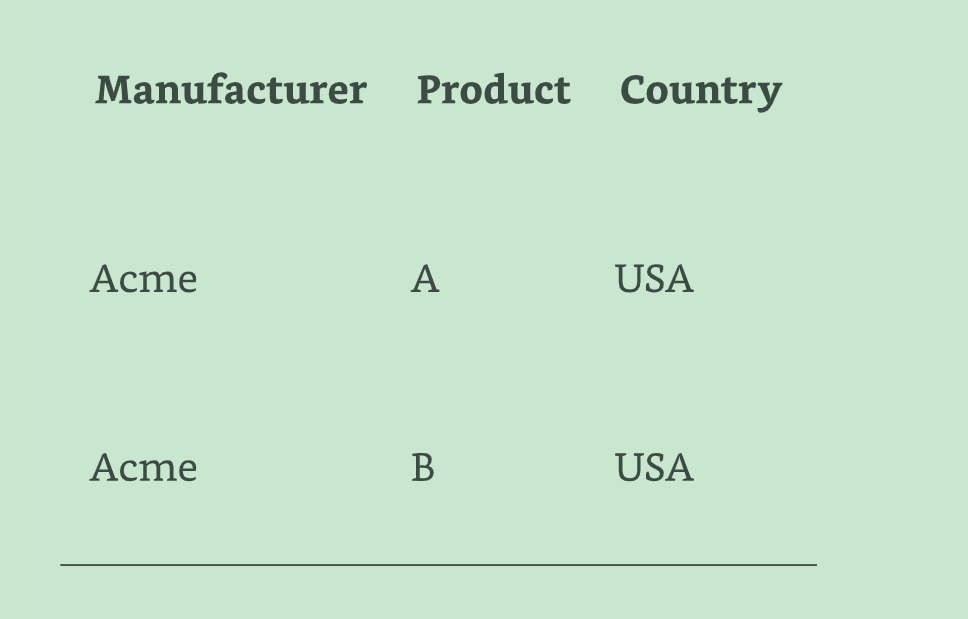

The group_by(Manufacturer) clause in the query would cause these two rows to be collapsed into one, since both have Acme as the manufacturer. A plain func.count() function given as the second value in the query would count the number of rows that were merged, which in this example is 2, even though there is a single country at play. The distinct() clause asks the database to remove duplicates from the count.

# Deleting from Many-to-Many Relationships

Many-to-Many relationships that are configured with the secondary option have the advantage that SQLAlchemy does all the maintenance work on the join table, and this extends to deletions. When an entity is deleted, SQLAlchemy finds all the entities on the other side of the relationship that linked to it and removes those links.

The following example deletes a country, which makes that country automatiaclly disappear from the products that had it listed:

In [16]:
c = session.get(Country, 22)
c

In [17]:
p = session.get(Product, 138)
p

Product(138, "Timex Sinclair 1000", "Manufacturer(70, "Timex Sinclair")", 1982, [Country(3, "USA")], "Z80")

In [18]:
p.countries

[Country(3, "USA")]

In [19]:
session.delete(c)
session.commit()


UnmappedInstanceError: Class 'builtins.NoneType' is not mapped

In [ ]:
p.countries

[Country(1, "UK"), Country(3, "USA")]

It is also possible to detach entities that are conected through a many-to-many relationship, without deleting any of the entities themselves. The detachment can be issued from either side of the relationship using list semantics:

In [ ]:
c = session.get(Country, 1)
c

Country(1, "UK")

In [ ]:
p = session.get(Product, 138)

In [ ]:
p

Product(138, "Timex Sinclair 1000", "Manufacturer(70, "Timex Sinclair")", 1982, [Country(1, "UK"), Country(3, "USA")], "Z80")

In [ ]:
p.countries

[Country(1, "UK"), Country(3, "USA")]

In [ ]:
c in p.countries

True

In [ ]:
p.countries.remove(c)
session.commit()
p.countries

[Country(3, "USA")]

In [ ]:
c in p.countries

False

The above example removes a country from a product. The same result can be obtained by removing the product from the country:

In [ ]:
c.products

[Product(1, "Acorn Atom", "Manufacturer(1, "Acorn Computers Ltd")", 1980, [Country(1, "UK")], "6502"),
 Product(2, "BBC Micro", "Manufacturer(1, "Acorn Computers Ltd")", 1981, [Country(1, "UK")], "6502"),
 Product(3, "Electron", "Manufacturer(1, "Acorn Computers Ltd")", 1983, [Country(1, "UK")], "6502"),
 Product(4, "BBC Master", "Manufacturer(1, "Acorn Computers Ltd")", 1986, [Country(1, "UK")], "65SC12"),
 Product(5, "Acorn Archimedes", "Manufacturer(1, "Acorn Computers Ltd")", 1987, [Country(1, "UK")], "ARM RISC"),
 Product(6, "A7000", "Manufacturer(1, "Acorn Computers Ltd")", 1995, [Country(1, "UK")], "ARM RISC"),
 Product(7, "CPC 464", "Manufacturer(2, "Amstrad")", 1984, [Country(1, "UK")], "Z80"),
 Product(8, "CPC 664", "Manufacturer(2, "Amstrad")", 1984, [Country(1, "UK")], "Z80"),
 Product(9, "CPC 6128", "Manufacturer(2, "Amstrad")", 1984, [Country(1, "UK")], "Z80"),
 Product(10, "464 Plus", "Manufacturer(2, "Amstrad")", 1990, [Country(1, "UK")], "Z80"),
 Product(11, "6128 Plus

In [ ]:
p in c.products

False

The one-to-many relationship between manufacturers and their products was configured with a non-nullable foreign key to force all products to have a manufacturer linked, effectively making it impossible for a product to exist without having a manufacturer. With a many-to-many relationship there is no automatic way to enforce that every entity has at least one link to an entity on the other side. The example below removes the only country associated with a product, leaving the product without any related countries:

In [ ]:
c = session.get(Country, 1)
c

Country(1, "UK")

In [ ]:
p = session.get(Product, 1)
p

Product(1, "Acorn Atom", "Manufacturer(1, "Acorn Computers Ltd")", 1980, [Country(1, "UK")], "6502")

In [ ]:
p in c.products

True

In [ ]:
c.products.remove(p)
session.commit()

In [ ]:
p.countries

[]

For a many-to-many relationship for which it is desired that there always is at least one linked entity the application must manually perform validation checks and prevent the last link from being removed.

# Database Migrations

The chapters that follow are going to introduce more tables and relationships. Before increasing the complexity of the datbase it would be a good idea to set up a robust mechanism to make updates, since the drop_all() and create_all() functions used until this point are very limited in that they require all the data to be re-imported.

# Introduction to Alembic

In this section you are going to learn how to use [Alembic](https://alembic.sqlalchemy.org/en/latest/), the database migration tool that is part of the SQLAlchemy family. Install this package in your .venv 

The first step to enable database migrations in your project is to create a migration repository with the alembic init command:

```bash
(venv) $ alembic init migrations
```

The migrations argument is the name of a subdirectory that is created under the project directory, where database migration scripts will be stored. In addition to this subdirectory, an _alembic.ini_ file is created in the project directory. For a project that is under source control, the _alembic.ini_ file and the entire contents of the _migrations_ subdirectory should be treated as source code and maintained along with the application's source files.